# Phase 2 - Cohort, Stats, Feature Engineering, Leakage Control

**Intended use:** Define the analysis cohort, explore risk factors, and export leakage-controlled gold features.

**Prerequisite:** Phase 0 silver data.


## 1. Setup


In [1]:
from __future__ import annotations
import json, hashlib, os, re, uuid, warnings, shutil
from pathlib import Path
from datetime import datetime, timezone
import numpy as np
import pandas as pd

warnings.filterwarnings("ignore")
ROOT = Path(".").resolve()
if not (ROOT / "datafile.txt").exists():
    ROOT = Path("..").resolve()
os.chdir(ROOT)
DATAFILE = ROOT / "datafile.txt"
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

def load_registry(path=DATAFILE):
    rows = []
    for line in Path(path).read_text(encoding="utf-8").splitlines():
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        parts = line.split("|")
        if len(parts) < 4:
            continue
        rows.append({"role": parts[0].strip(), "zone": parts[1].strip(), "path": parts[2].strip(), "description": parts[3].strip()})
    return pd.DataFrame(rows)

def registry_paths(role=None):
    reg = load_registry()
    if role is not None:
        reg = reg[reg["role"] == role]
    return [ROOT / p for p in reg["path"].tolist()]

def registry_path(role, default=None):
    paths = registry_paths(role=role)
    if paths:
        return paths[0]
    return ROOT / default if default else None

def upsert_registry(role, zone, rel_path, description):
    lines = DATAFILE.read_text(encoding="utf-8").splitlines()
    new_line = f"{role}|{zone}|{rel_path}|{description}"
    out, found = [], False
    for line in lines:
        if line.startswith("#") or not line.strip():
            out.append(line)
            continue
        parts = line.split("|")
        if len(parts) >= 3 and parts[0].strip() == role and parts[2].strip() == rel_path:
            out.append(new_line)
            found = True
        else:
            out.append(line)
    if not found:
        out.append(new_line)
    DATAFILE.write_text("\n".join(out) + "\n", encoding="utf-8")

def new_run_id():
    return datetime.now(timezone.utc).strftime("%Y%m%dT%H%M%SZ") + "_" + uuid.uuid4().hex[:8]

def file_checksum(path: Path) -> str:
    h = hashlib.sha256()
    with open(path, "rb") as f:
        for chunk in iter(lambda: f.read(1 << 20), b""):
            h.update(chunk)
    return h.hexdigest()

print("ROOT:", ROOT)
print(load_registry())


ROOT: E:\Amit\Project\Hospital project
           role    zone                                       path  \
0           raw  bronze                 data/raw/diabetic_data.csv   
1         clean  silver        data/lake/silver/encounters.parquet   
2      features    gold      data/lake/gold/model_features.parquet   
3     sequences    gold       data/lake/gold/rnn_sequences.parquet   
4   predictions    gold    data/lake/gold/test_predictions.parquet   
5       metrics    gold  data/lake/gold/experiment_results.parquet   
6          mart  export          data/exports/mart_readmission.csv   
7          mart  export        data/exports/mart_clinical_risk.csv   
8          mart  export    data/exports/mart_model_performance.csv   
9          mart  export         data/exports/mart_dq_scorecard.csv   
10     manifest     ops    data/lake/bronze/_manifests/latest.json   
11     champion     ops              models/champion_register.json   
12  hyperparams     ops                    models/h

## 2. Load silver and define cohort labels

Primary outcome: 30-day readmission (`<30`). 60/90-day labels are **proxies** (any readmission), not true calendar follow-up.


In [2]:
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from scipy import stats

silver_path = registry_path("clean", "data/lake/silver/encounters.parquet")
df = pd.read_parquet(silver_path)
print("input", df.shape)

work = df.copy()
work["readmit_30d"] = (work["readmitted"] == "<30").astype(int)
work["readmit_60d_proxy"] = work["readmitted"].isin(["<30", ">30"]).astype(int)
work["readmit_90d_proxy"] = work["readmit_60d_proxy"]
print(work[["readmit_30d", "readmit_60d_proxy"]].mean())


input (101766, 50)
readmit_30d          0.111599
readmit_60d_proxy    0.460881
dtype: float64


## 3. Missingness profile

Understand which fields need imputation or exclusion later.


In [3]:
miss = work.isna().mean().sort_values(ascending=False)
print("Top missing:\n", miss.head(10))


Top missing:
 max_glu_serum               0.947468
A1Cresult                   0.832773
race                        0.000000
patient_nbr                 0.000000
encounter_id                0.000000
weight                      0.000000
admission_type_id           0.000000
discharge_disposition_id    0.000000
admission_source_id         0.000000
time_in_hospital            0.000000
dtype: float64


## 4. EDA - readmission distribution

Brief-required chart 1 of 5.


Saved 01_readmission_distribution.png


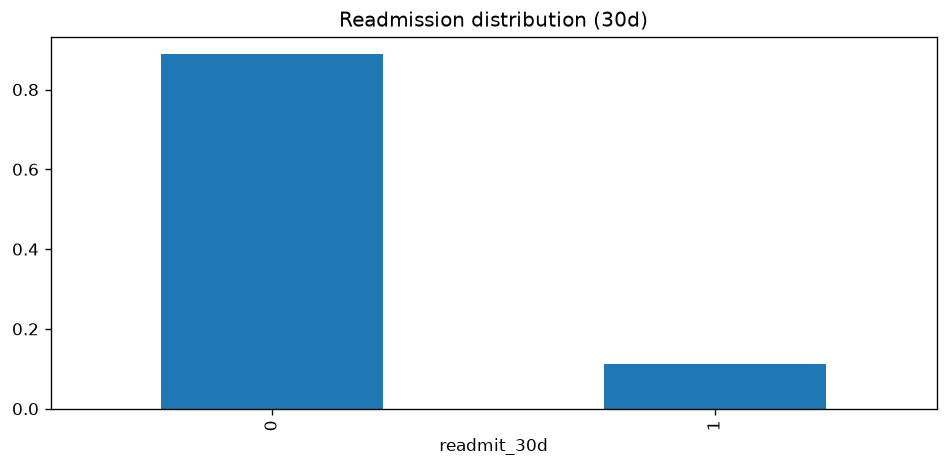

readmit_30d
0    0.888401
1    0.111599
Name: proportion, dtype: float64

In [4]:
eda_dir = ROOT / "data" / "exports" / "eda"
eda_dir.mkdir(parents=True, exist_ok=True)

from IPython.display import display, Image

def show_saved(path):
    display(Image(filename=str(path)))

def save_bar(series, title, fname):
    series.plot(kind="bar", figsize=(8, 4), title=title)
    plt.tight_layout()
    out = eda_dir / fname
    plt.savefig(out, dpi=120, bbox_inches="tight")
    plt.close()
    print(f"Saved {fname}")
    show_saved(out)

def save_line(series, title, fname, xlabel=None, ylabel="Readmission rate"):
    series.sort_index().plot(kind="line", figsize=(8, 4), title=title, marker="o")
    plt.xlabel(xlabel or "Length of stay (days)")
    plt.ylabel(ylabel)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    out = eda_dir / fname
    plt.savefig(out, dpi=120, bbox_inches="tight")
    plt.close()
    print(f"Saved {fname}")
    show_saved(out)

save_bar(work["readmit_30d"].value_counts(normalize=True), "Readmission distribution (30d)", "01_readmission_distribution.png")
work["readmit_30d"].value_counts(normalize=True)

## 5. EDA - age vs readmission

Brief-required chart 2 of 5.


Saved 02_age_vs_readmission.png


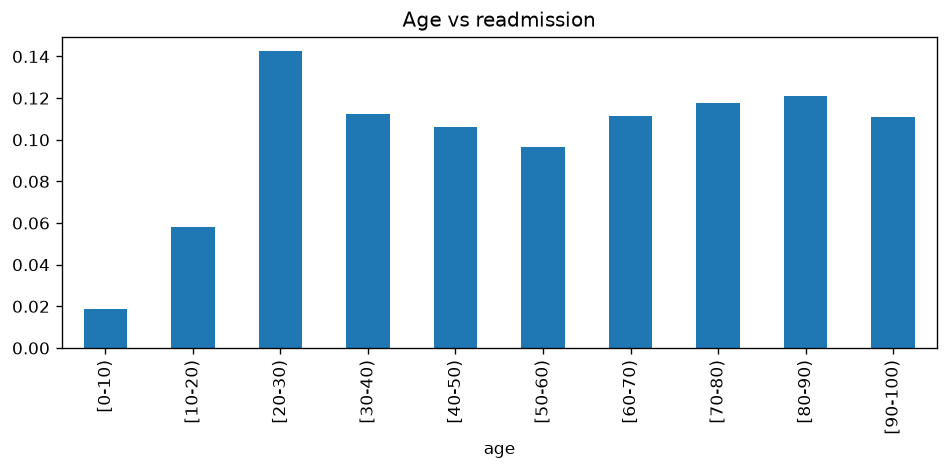

age
[0-10)      0.018634
[10-20)     0.057887
[20-30)     0.142426
[30-40)     0.112318
[40-50)     0.106040
[50-60)     0.096662
[60-70)     0.111284
[70-80)     0.117731
[80-90)     0.120835
[90-100)    0.110992
Name: readmit_30d, dtype: float64

In [5]:
save_bar(work.groupby("age")["readmit_30d"].mean(), "Age vs readmission", "02_age_vs_readmission.png")
work.groupby("age")["readmit_30d"].mean()

## 6. EDA - length of stay vs readmission

Brief-required chart 3 of 5.


Saved 03_los_vs_readmission.png


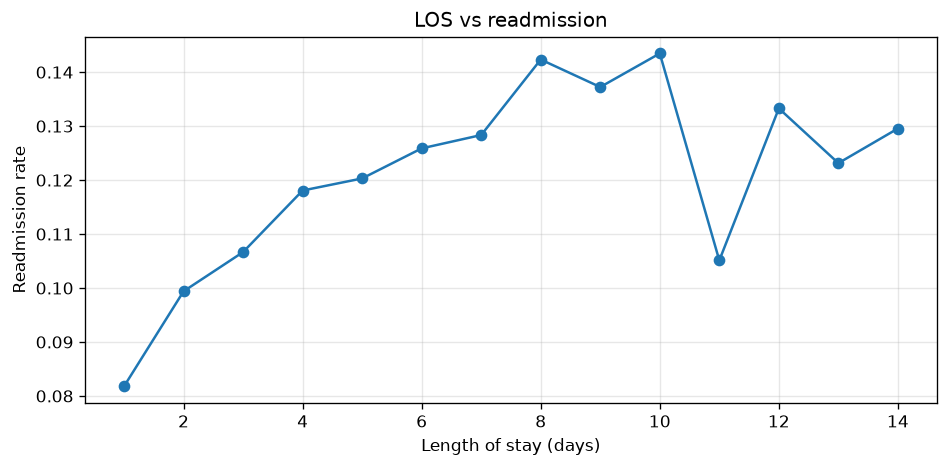

time_in_hospital
1     0.081785
2     0.099396
3     0.106668
4     0.118070
5     0.120309
6     0.125879
7     0.128350
8     0.142337
9     0.137242
10    0.143467
11    0.105121
12    0.133287
13    0.123140
14    0.129559
Name: readmit_30d, dtype: float64

In [6]:
los_rate = work.groupby("time_in_hospital")["readmit_30d"].mean()
save_line(los_rate, "LOS vs readmission", "03_los_vs_readmission.png", xlabel="Length of stay (days)")
los_rate

## 7. EDA - medication (insulin) impact

Brief-required chart 4 of 5.


Saved 04_medication_impact.png


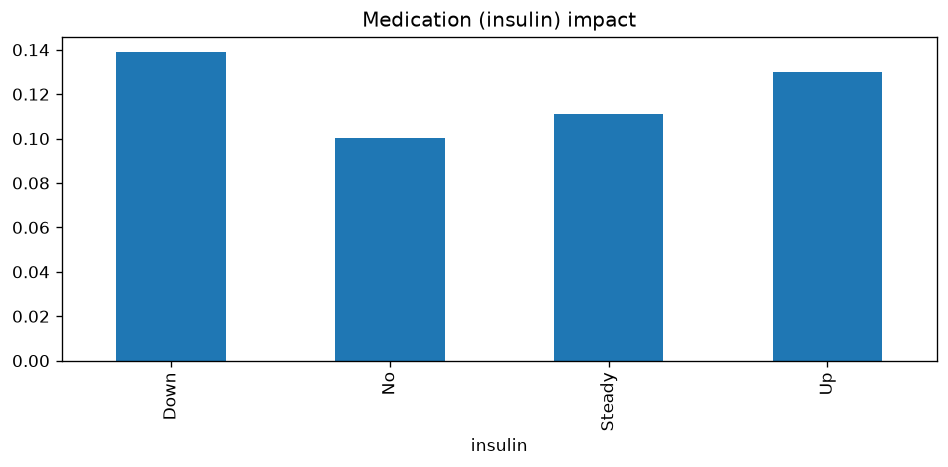

insulin
Down      0.138975
No        0.100374
Steady    0.111284
Up        0.129905
Name: readmit_30d, dtype: float64

In [7]:
if "insulin" in work.columns:
    save_bar(work.groupby("insulin")["readmit_30d"].mean(), "Medication (insulin) impact", "04_medication_impact.png")
    display_df = work.groupby("insulin")["readmit_30d"].mean()
else:
    display_df = None
display_df

## 8. EDA - admission type impact

Brief-required chart 5 of 5.


Saved 05_admission_type_impact.png


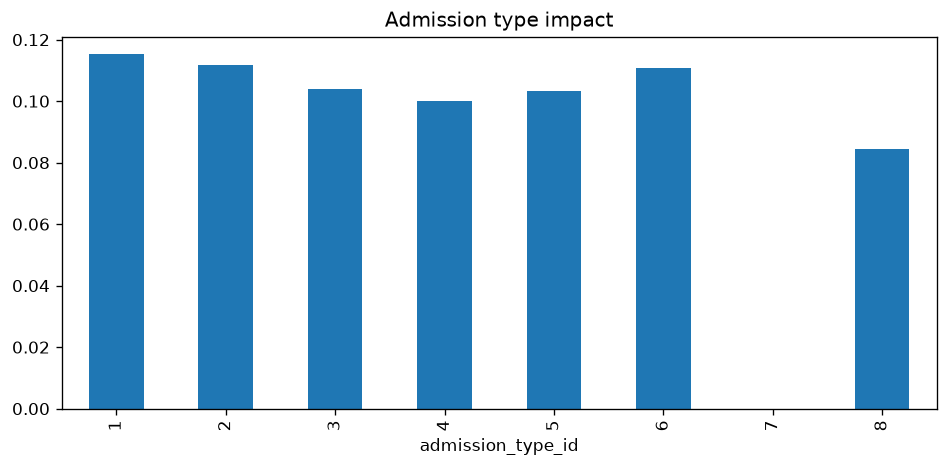

admission_type_id
1    0.115225
2    0.111797
3    0.103927
4    0.100000
5    0.103448
6    0.110754
7    0.000000
8    0.084375
Name: readmit_30d, dtype: float64

In [8]:
save_bar(work.groupby("admission_type_id")["readmit_30d"].mean(), "Admission type impact", "05_admission_type_impact.png")
work.groupby("admission_type_id")["readmit_30d"].mean()

## 9. Inferential statistics

Chi-square (gender) and Mann-Whitney (LOS). Interpret as associations, not clinical causation.


In [9]:
cont = pd.crosstab(work["gender"], work["readmit_30d"])
chi2, p, dof, exp = stats.chi2_contingency(cont)
print(f"Chi-square gender vs readmit: chi2={chi2:.3f} p={p:.4g}")
los_1 = work.loc[work["readmit_30d"] == 1, "time_in_hospital"]
los_0 = work.loc[work["readmit_30d"] == 0, "time_in_hospital"]
u, p_u = stats.mannwhitneyu(los_1, los_0, alternative="two-sided")
print(f"Mann-Whitney LOS: U={u:.1f} p={p_u:.4g}")


Chi-square gender vs readmit: chi2=1.237 p=0.5387
Mann-Whitney LOS: U=560893881.0 p=2.69e-59


## 10. Feature engineering

Active medication count, total visits, lab presence flags.


In [10]:
med_cols = [c for c in work.columns if c in {
    "metformin","repaglinide","nateglinide","chlorpropamide","glimepiride","acetohexamide",
    "glipizide","glyburide","tolbutamide","pioglitazone","rosiglitazone","acarbose","miglitol",
    "troglitazone","tolazamide","examide","citoglipton","insulin","glyburide-metformin",
    "glipizide-metformin","glimepiride-pioglitazone","metformin-rosiglitazone","metformin-pioglitazone"
}]
work["active_med_count"] = work[med_cols].isin(["Steady", "Up", "Down"]).sum(axis=1)
work["total_visits"] = work[["number_outpatient", "number_emergency", "number_inpatient"]].sum(axis=1)
work["has_A1C"] = work["A1Cresult"].notna().astype(int) if "A1Cresult" in work.columns else 0
work["has_max_glu"] = work["max_glu_serum"].notna().astype(int) if "max_glu_serum" in work.columns else 0
print(work[["active_med_count", "total_visits", "has_A1C"]].describe())


       active_med_count   total_visits        has_A1C
count     101766.000000  101766.000000  101766.000000
mean           1.179706       1.202759       0.167227
std            0.920190       2.291781       0.373180
min            0.000000       0.000000       0.000000
25%            1.000000       0.000000       0.000000
50%            1.000000       0.000000       0.000000
75%            2.000000       2.000000       0.000000
max            6.000000      80.000000       1.000000


## 11. Leakage denylist and gold feature export

IDs and labels never enter the model feature list.


In [11]:
LEAKAGE = {"encounter_id", "patient_nbr", "readmitted", "readmit_30d", "readmit_60d_proxy", "readmit_90d_proxy"}

feature_cols = [
    "race","gender","age","admission_type_id","discharge_disposition_id","admission_source_id",
    "time_in_hospital","num_lab_procedures","num_procedures","num_medications",
    "number_outpatient","number_emergency","number_inpatient","number_diagnoses",
    "diag_1","change","diabetesMed","active_med_count","total_visits","has_A1C","has_max_glu",
    "insulin","metformin","A1Cresult","max_glu_serum",
]
feature_cols = [c for c in feature_cols if c in work.columns]
assert not set(feature_cols) & LEAKAGE

extra_cols = ["readmit_30d", "readmit_60d_proxy", "readmit_90d_proxy", "encounter_id", "patient_nbr", "gender", "age"]
features = work[list(dict.fromkeys(feature_cols + extra_cols))].copy()

feat_path = ROOT / "data" / "lake" / "gold" / "model_features.parquet"
feat_path.parent.mkdir(parents=True, exist_ok=True)
features.to_parquet(feat_path, index=False)
upsert_registry("features", "gold", "data/lake/gold/model_features.parquet", "Leakage-controlled model-ready features")
print("Features:", features.shape)
print("Feature columns:", feature_cols)


Features: (101766, 30)
Feature columns: ['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'admission_source_id', 'time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient', 'number_emergency', 'number_inpatient', 'number_diagnoses', 'diag_1', 'change', 'diabetesMed', 'active_med_count', 'total_visits', 'has_A1C', 'has_max_glu', 'insulin', 'metformin', 'A1Cresult', 'max_glu_serum']


## 12. RNN sequences and feature dictionary

Diagnosis/medication token sequences for the sequence model; cohort notes for documentation.


In [12]:
seq = work[["encounter_id", "diag_1", "diag_2", "diag_3", "insulin", "metformin",
            "readmit_30d", "readmit_60d_proxy", "readmit_90d_proxy"]].copy()
seq_path = ROOT / "data" / "lake" / "gold" / "rnn_sequences.parquet"
seq.to_parquet(seq_path, index=False)
upsert_registry("sequences", "gold", "data/lake/gold/rnn_sequences.parquet", "RNN diagnosis/med sequence features")

feature_dictionary = {
    "features": feature_cols,
    "leakage_denylist": sorted(LEAKAGE),
    "cohort": {
        "index_encounter": "one row per admission/encounter in Diabetes 130",
        "primary_outcome": "readmit_30d (<30)",
        "proxy_horizons": "60/90 use any readmission (<30 or >30) - not true calendar follow-up",
        "exclusions_not_applicable": ["in-hospital death", "transfer", "planned readmission - fields absent"],
    },
}
(ROOT / "data" / "nosql" / "feature_dictionary.json").write_text(json.dumps(feature_dictionary, indent=2), encoding="utf-8")
print("Sequences:", seq.shape)


Sequences: (101766, 9)


## 13. Phase 2 summary


In [13]:
print("Phase 2 complete", features.shape)
print("EDA charts in:", eda_dir)


Phase 2 complete (101766, 30)
EDA charts in: E:\Amit\Project\Hospital project\data\exports\eda
